# Практика 6 Шумовые признаки и Ridge
Повторяю подготовку практики 5 на том же housing.csv, тех же признаках и разделении 70/30 с random_state=42. Добавляю ровно 30 случайных признаков. Проверяю, создают ли они переобучение и помогает ли Ridge. Обязательную таблицу alpha выбираю по test, как указано в методичке. Такая оценка после выбора уже не является независимой финальной проверкой.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')


df=pd.read_csv(BASE/'data'/'housing.csv')
# Среднее число комнат на домохозяйство удобнее общего числа комнат района.
df['rooms_per_household']=df['total_rooms']/df['households']
features=['median_income','housing_median_age','rooms_per_household']
target='median_house_value'
data=df[features+[target]].replace([np.inf,-np.inf],np.nan).dropna()
X,y=data[features],data[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

Python: 3.10.20


Базовая R2 train: 0.5118542514153737 test: 0.5126516784926669


,alpha,R2 train,R2 test
0,0.1,0.512467,0.511893
1,1.0,0.512467,0.511892
2,10.0,0.512467,0.511888
3,100.0,0.512435,0.511819
4,1000.0,0.509720,0.508797


,Условия,R2 train,R2 test
0,Базовая,0.511854,0.512652
1,LinearRegression + шум,0.512467,0.511893
2,"Ridge + шум, alpha=0.1",0.512467,0.511893


Падение R2: 0.0007590928566667543
Лучшее alpha: 0.1
До базового качества осталось: 0.0007591352267525275


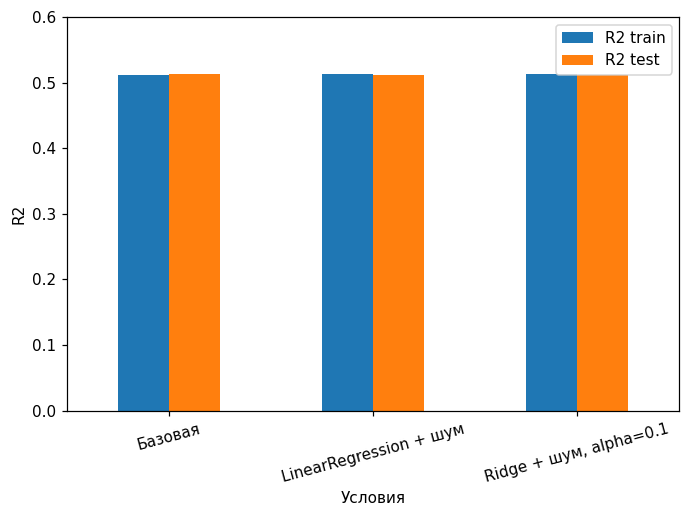

In [2]:
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import r2_score
scaler=StandardScaler()
A_train=scaler.fit_transform(X_train)
A_test=scaler.transform(X_test)
base=LinearRegression().fit(A_train,y_train)
base_train=r2_score(y_train,base.predict(A_train))
base_test=r2_score(y_test,base.predict(A_test))
print('Базовая R2 train:',base_train,'test:',base_test)
# Разные массивы шума независимы от цен и друг от друга.
rng=np.random.RandomState(42)
noise_train=rng.normal(size=(len(X_train),30))
noise_test=rng.normal(size=(len(X_test),30))
B_train=np.hstack([X_train.to_numpy(),noise_train])
B_test=np.hstack([X_test.to_numpy(),noise_test])
scaler_noise=StandardScaler()
B_train=scaler_noise.fit_transform(B_train)
B_test=scaler_noise.transform(B_test)
noisy=LinearRegression().fit(B_train,y_train)
noisy_train=r2_score(y_train,noisy.predict(B_train))
noisy_test=r2_score(y_test,noisy.predict(B_test))
alpha_values=[0.1,1,10,100,1000]
ridge_rows=[]
for alpha in alpha_values:
    model=Ridge(alpha=alpha).fit(B_train,y_train)
    ridge_rows.append({'alpha':alpha,'R2 train':r2_score(y_train,model.predict(B_train)),
                      'R2 test':r2_score(y_test,model.predict(B_test))})
ridge_results=pd.DataFrame(ridge_rows)
display(ridge_results)
ridge_results.to_csv(BASE/'results'/'practice6_alpha.csv',index=False)
best=ridge_results.loc[ridge_results['R2 test'].idxmax()]
summary=pd.DataFrame([
    {'Условия':'Базовая','R2 train':base_train,'R2 test':base_test},
    {'Условия':'LinearRegression + шум','R2 train':noisy_train,'R2 test':noisy_test},
    {'Условия':f'Ridge + шум, alpha={best["alpha"]}','R2 train':best['R2 train'],'R2 test':best['R2 test']}])
display(summary)
summary.to_csv(BASE/'results'/'practice6.csv',index=False)
print('Падение R2:',base_test-noisy_test)
print('Лучшее alpha:',best['alpha'])
print('До базового качества осталось:',base_test-best['R2 test'])
summary.plot.bar(x='Условия',y=['R2 train','R2 test'],ylim=(0,0.6))
plt.ylabel('R2');plt.xticks(rotation=15)
save_plot('p6_comparison.png')
save_json('practice6.json',{'base_test':base_test,'noisy_test':noisy_test,
    'best_alpha':float(best['alpha']),'ridge_test':float(best['R2 test'])})

## Ответы по обязательному эксперименту
Результаты выше показывают очень небольшое падение качества. На полном наборе 14 448 тренировочных примеров 30 шумовых признаков не создали сильного переобучения. Лучшее alpha выбирается из заданной пятёрки, но Ridge почти не восстановил качество. Называть это «спасением модели» было бы неверно.

## Дополнительная демонстрация переобучения
Чтобы показать смысл задания, отдельно ограничиваю train первыми 100 примерами уже случайно перемешанного train. Размер 100 фиксирую заранее, без подбора по test. Данные, три полезных признака и 30 шумовых признаков остаются теми же. Основной эксперимент выше не заменяю. В этой демонстрации alpha выбираю по CV только малого train, затем один раз проверяю выбранный Ridge на прежнем test.

In [3]:
from sklearn.model_selection import GridSearchCV,KFold
small_X=X_train.iloc[:100]
small_y=y_train.iloc[:100]
# Беру первые 100 строк того же заранее созданного шума.
small_noise=np.hstack([small_X.to_numpy(),noise_train[:100]])
test_noise=np.hstack([X_test.to_numpy(),noise_test])
small_base=Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]).fit(small_X,small_y)
small_noisy=Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]).fit(small_noise,small_y)
search=GridSearchCV(Pipeline([('scaler',StandardScaler()),('model',Ridge())]),
    {'model__alpha':alpha_values},cv=KFold(5,shuffle=True,random_state=42),scoring='r2')
search.fit(small_noise,small_y)
demo=pd.DataFrame([
    {'Условия':'100 примеров без шума','R2 train':small_base.score(small_X,small_y),'R2 test':small_base.score(X_test,y_test)},
    {'Условия':'100 примеров с шумом','R2 train':small_noisy.score(small_noise,small_y),'R2 test':small_noisy.score(test_noise,y_test)},
    {'Условия':f'Ridge, alpha={search.best_params_["model__alpha"]}','R2 train':search.score(small_noise,small_y),'R2 test':search.score(test_noise,y_test)}])
display(demo)
demo.to_csv(BASE/'results'/'practice6_demo.csv',index=False)
print('Alpha выбрано по CV:',search.best_params_)
print('Изменение test после Ridge:',demo.iloc[2]['R2 test']-demo.iloc[1]['R2 test'])

,Условия,R2 train,R2 test
0,100 примеров без шума,0.503820,0.486507
1,100 примеров с шумом,0.621133,0.272592
2,"Ridge, alpha=100",0.439559,0.359773


Alpha выбрано по CV: {'model__alpha': 100}
Изменение test после Ridge: 0.08718131413727148


## Вывод
Количество наблюдений относительно количества признаков влияет на переобучение. Дополнительная таблица позволяет сравнить эффект шума при малом train с основным экспериментом. Ridge уменьшает величину коэффициентов, но не гарантирует восстановление качества до исходного уровня. Я обсуждаю только полученные числа.